<a href="https://colab.research.google.com/github/Tauhid-Topu-007/DEPRESSION-AND-ANXIETY-DETECTION-MODEL-FOR-STUDENTS/blob/main/DDNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DDNet: Depression Detection Network (20-Fold Cross Validation)

PART 1: DATA LOADING AND EXPLORATION

Dataset Shape: (2966, 14)
Columns: ['age', 'age_group', 'gender', 'stress_level', 'anxiety_score', 'depression_score', 'combined_mental_health_score', 'risk_category', 'sleep_quality', 'sleep_hours', 'social_support', 'physical_activity_days', 'mental_health_condition', 'source']

Data Types:
age                               int64
age_group                        object
gender                           object
stress_level                     object
anxiety_score                   float64
depression_score                float64
combined_mental_health_score    float64
risk_category                    object
sleep_quality                    object
sleep_hours                     float64
social_support                  float64
physical_activity_days          float64
mental_health_condition          object
source                           object
dtype: object

Missing Values:
age          

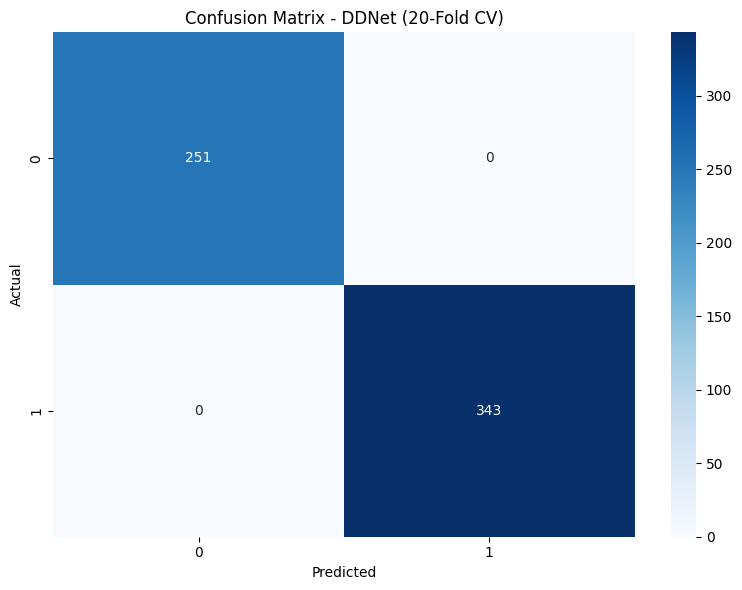

Confusion matrix saved as 'confusion_matrix.png'


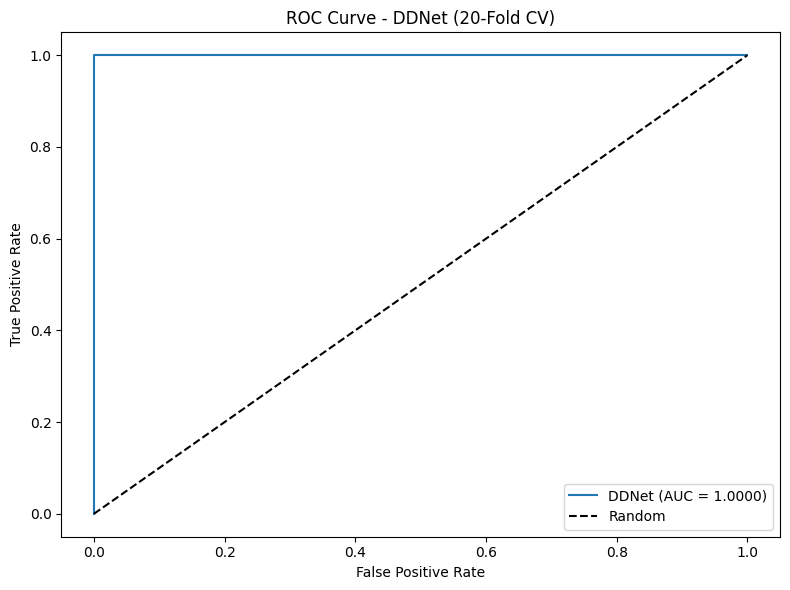

ROC curve saved as 'roc_curve.png'


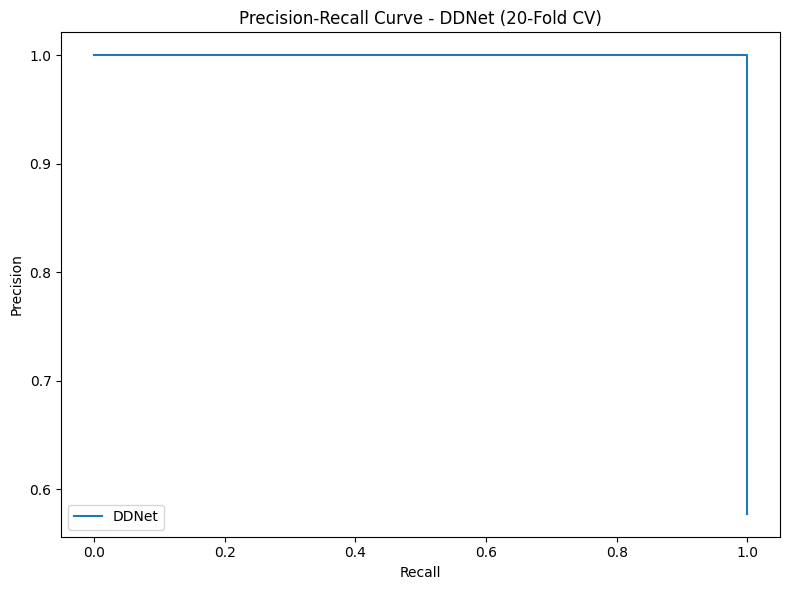

Precision-Recall curve saved as 'precision_recall_curve.png'

6.4 Feature Importance from Random Forest (Reference):

Top 10 Features:
                        Feature  Importance
3  combined_mental_health_score    0.604276
2              depression_score    0.208295
1                 anxiety_score    0.163052
0                  stress_level    0.016109
4       mental_health_condition    0.008269


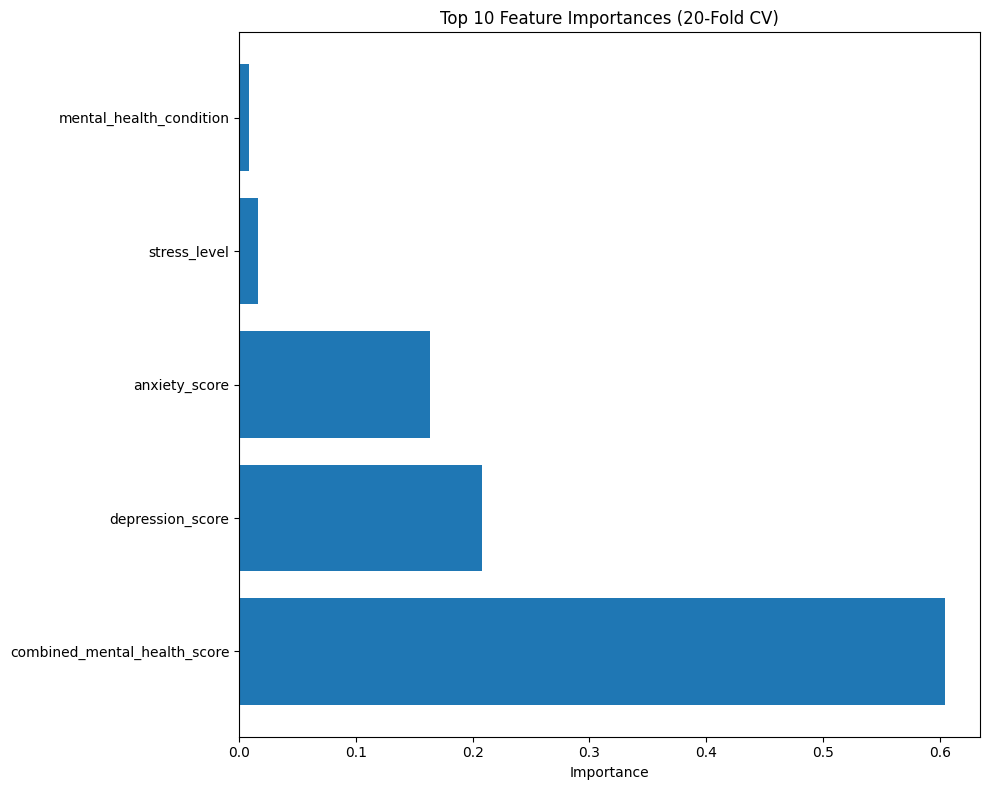

Feature importance saved as 'feature_importance.png'

PART 7: COMPARISON WITH OTHER ML MODELS (20-Fold CV)

7.1 Training other ML models for comparison...
  Training Logistic Regression with 20-fold CV...
    Logistic Regression CV Accuracy: 1.0000 (+/- 0.0000)
    Logistic Regression Test Accuracy: 1.0000
  Training Naive Bayes with 20-fold CV...
    Naive Bayes CV Accuracy: 0.9792 (+/- 0.0116)
    Naive Bayes Test Accuracy: 0.9697
  Training Decision Tree with 20-fold CV...
    Decision Tree CV Accuracy: 1.0000 (+/- 0.0000)
    Decision Tree Test Accuracy: 1.0000
  Training Random Forest with 20-fold CV...
    Random Forest CV Accuracy: 1.0000 (+/- 0.0000)
    Random Forest Test Accuracy: 1.0000
  Training Extra Trees with 20-fold CV...
    Extra Trees CV Accuracy: 1.0000 (+/- 0.0000)
    Extra Trees Test Accuracy: 0.9983
  Training Gradient Boosting with 20-fold CV...
    Gradient Boosting CV Accuracy: 1.0000 (+/- 0.0000)
    Gradient Boosting Test Accuracy: 1.0000
  Training SVM wi

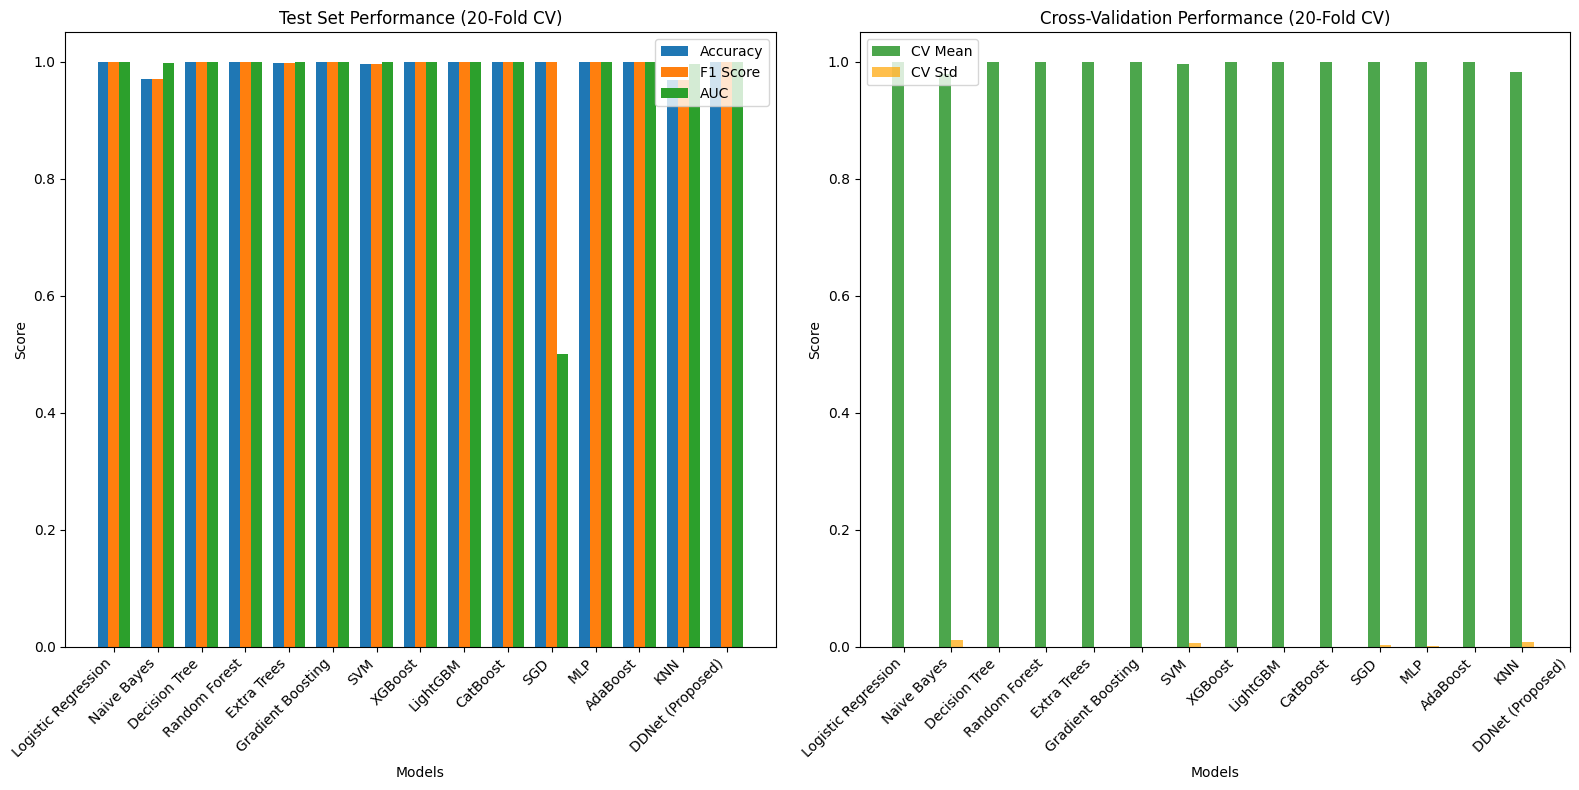

Model comparison saved as 'model_comparison.png'

PART 8: SHAP EXPLAINABLE AI (20-Fold CV)

8.1 Computing SHAP values...
Expected value: 0.5012
SHAP values shape: (594, 5, 2)

8.2 SHAP Feature Importance...

Top 10 Most Important Features (Overall):
                     Feature  Mean Absolute SHAP
     mental_health_condition            0.079297
combined_mental_health_score            0.069842
            depression_score            0.069842
               anxiety_score            0.009022
                stress_level            0.009022


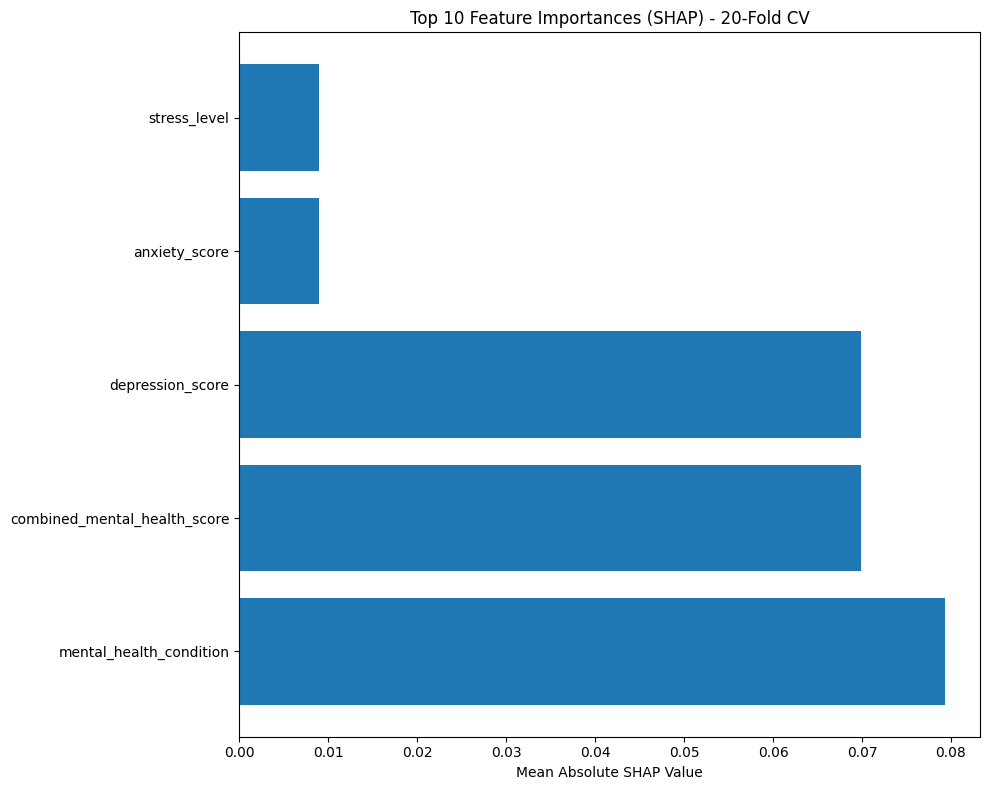


SHAP feature importance saved as 'shap_feature_importance.png'

8.3 SHAP Summary Plot...


<Figure size 1200x800 with 0 Axes>

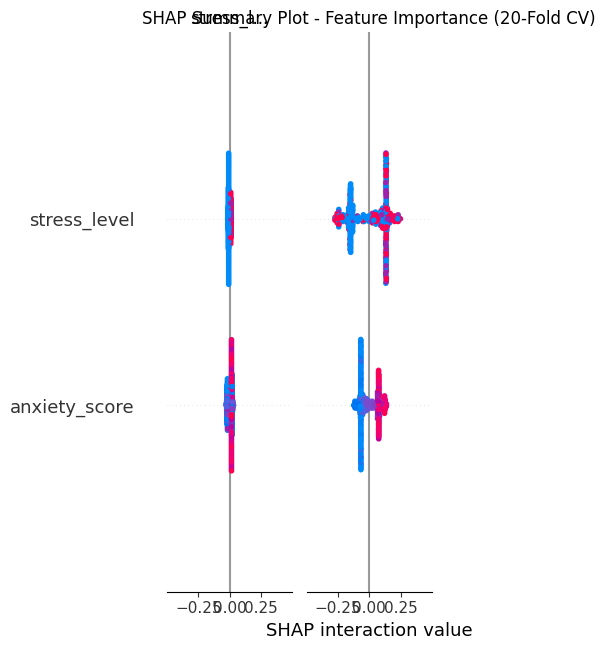

SHAP summary plot saved as 'shap_summary_plot.png'

8.4 SHAP Bar Plot...


<Figure size 1000x800 with 0 Axes>

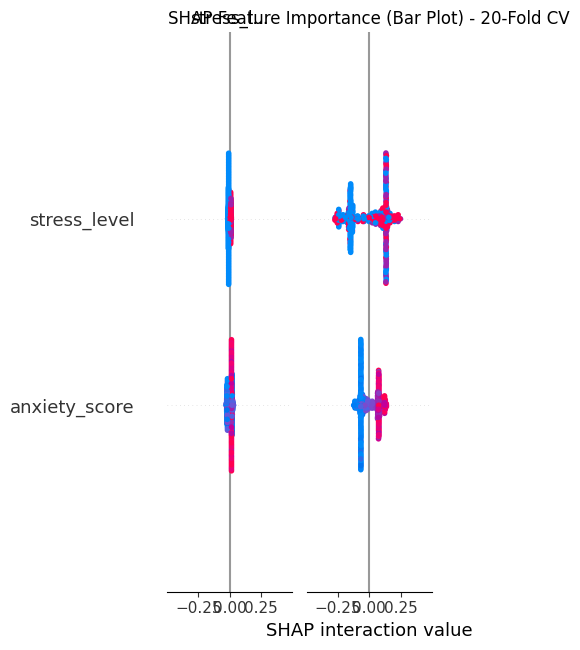

SHAP bar plot saved as 'shap_bar_plot.png'

8.5 Individual Prediction Explanation...
Sample 0:
  Actual Label: Low/Moderate Risk
  Predicted Probability: 0.0000
  Base Value: 0.5012
Individual explanation error: All arrays must be of the same length

9.0 SHAP Analysis Summary

Top 10 Most Important Features (Overall):
                     Feature  Mean Absolute SHAP
     mental_health_condition            0.079297
combined_mental_health_score            0.069842
            depression_score            0.069842
               anxiety_score            0.009022
                stress_level            0.009022

Top 5 Features by Mean Absolute SHAP:
  mental_health_condition: 0.0793
  combined_mental_health_score: 0.0698
  depression_score: 0.0698
  anxiety_score: 0.0090
  stress_level: 0.0090

SHAP Analysis Complete!

SHAP feature importance saved to 'shap_feature_importance.csv'

PART 10: UNCERTAINTY ANALYSIS (Monte Carlo Dropout) with 20-Fold CV

10.1 Performing uncertainty analysis...
 

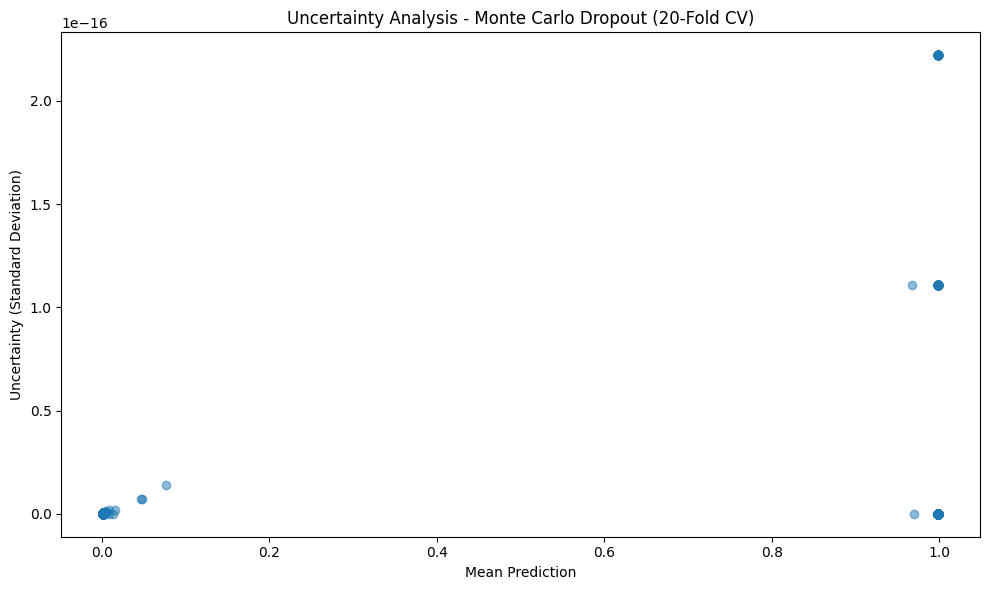

Uncertainty plot saved as 'uncertainty_plot.png'


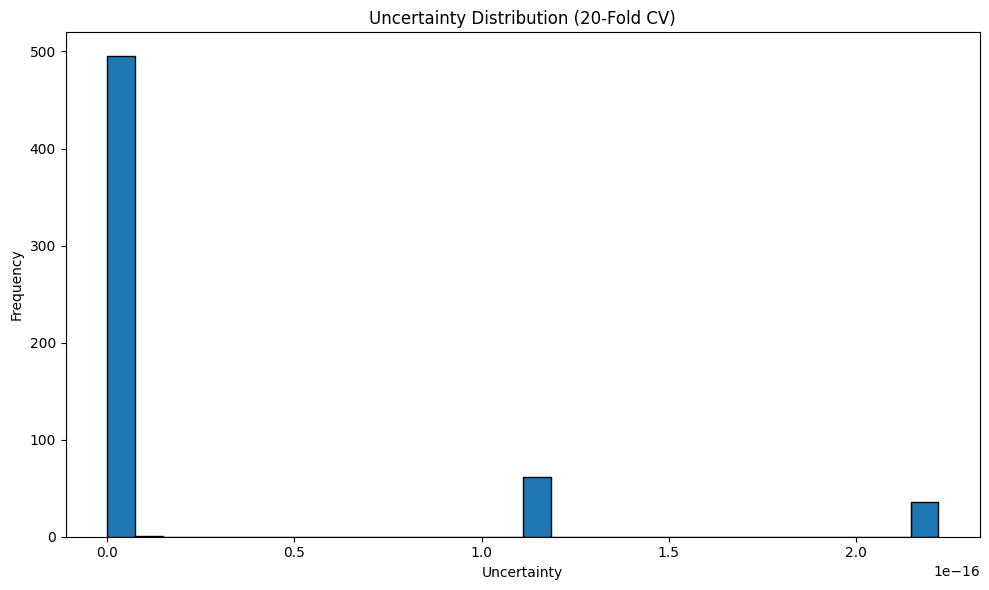

Uncertainty histogram saved as 'uncertainty_histogram.png'

PART 11: FINAL SUMMARY (20-Fold Cross Validation)

DDNet Model Summary (20-Fold CV)
Dataset Size: 2966 samples
Features: 5 features (after selection)
Training Samples: 2738 (after SMOTE)
Test Samples: 594
Cross-Validation Folds: 20

Model Architecture:
  Stage 1: MLP-1, MLP-2, SGD (Base Classifiers)
  Stage 2: MLP-3, CatBoost (Secondary Classifiers)
  Stage 3: LASSO (Meta-Classifier)

Performance Metrics:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1 Score: 1.0000
  AUC: 1.0000
  Log Loss: 0.4746
  Cohen's Kappa: 1.0000

XAI: SHAP analysis completed
Uncertainty: Monte Carlo Dropout analysis completed

Model Comparison (20-Fold CV):
              Model  Accuracy  F1 Score      AUC  CV Mean   CV Std
Logistic Regression  1.000000  1.000000 1.000000 1.000000 0.000000
        Naive Bayes  0.969697  0.969756 0.997932 0.979178 0.011633
      Decision Tree  1.000000  1.000000 1.000000 1.000000 0.000000
      Random Fore

In [11]:
"""
DDNet: Depression Detection Network - Complete Implementation (20-Fold CV)
Based on: Mumenin et al., IEEE Access 2025

Applied to: Unified Mental Health Dataset
Features: age, age_group, gender, stress_level, anxiety_score, depression_score,
          combined_mental_health_score, risk_category, sleep_quality, sleep_hours,
          social_support, physical_activity_days, mental_health_condition, source
"""

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Data Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.feature_selection import SelectKBest, f_classif, RFECV
from imblearn.over_sampling import SMOTE

# Machine Learning Models
from sklearn.linear_model import LogisticRegression, SGDClassifier, LassoCV
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, log_loss, cohen_kappa_score, confusion_matrix,
                             roc_curve, precision_recall_curve, classification_report)
from sklearn.model_selection import cross_val_score

# XAI
import shap

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Random Seed for Reproducibility
SEED = 42
N_FOLDS = 20  # As used in Paper 2
np.random.seed(SEED)

print("="*70)
print("DDNet: Depression Detection Network (20-Fold Cross Validation)")
print("="*70)

# ============================================================================
# PART 1: DATA LOADING AND EXPLORATION
# ============================================================================

print("\n" + "="*70)
print("PART 1: DATA LOADING AND EXPLORATION")
print("="*70)

# Load the dataset
df = pd.read_csv('unified_mental_health_dataset_cleaned.csv')
print(f"\nDataset Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

print(f"\nData Types:\n{df.dtypes}")

print(f"\nMissing Values:\n{df.isnull().sum()}")

# Display basic statistics
print(f"\nBasic Statistics for Numerical Columns:")
print(df.describe())

print(f"\nCategorical Columns Distribution:")
for col in df.select_dtypes(include=['object']).columns:
    print(f"\n{col}:")
    print(df[col].value_counts())

# ============================================================================
# PART 2: DATA PREPROCESSING
# ============================================================================

print("\n" + "="*70)
print("PART 2: DATA PREPROCESSING")
print("="*70)

# 2.1: Handle Missing Values
print("\n2.1 Handling Missing Values...")
missing_cols = df.columns[df.isnull().any()].tolist()
if missing_cols:
    print(f"Columns with missing values: {missing_cols}")
    for col in missing_cols:
        if df[col].dtype in ['int64', 'float64']:
            df[col].fillna(df[col].median(), inplace=True)
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)
    print("Missing values filled.")
else:
    print("No missing values found.")

# 2.2: Remove Duplicates
print("\n2.2 Removing Duplicates...")
duplicates = df.duplicated().sum()
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Removed {duplicates} duplicate rows. New shape: {df.shape}")
else:
    print("No duplicates found.")

# 2.3: Define Target Variable (Binary Classification)
print("\n2.3 Defining Target Variable...")

# Create binary target: 1 = High Risk (Depression), 0 = Low/Moderate Risk
df['target'] = df['risk_category'].apply(lambda x: 1 if x == 'High Risk' else 0)

print(f"Target distribution (Binary):")
print(df['target'].value_counts())
print(f"Target distribution (%):")
print(df['target'].value_counts(normalize=True) * 100)

# 2.4: Encode Categorical Features (Label Encoding)
print("\n2.4 Encoding Categorical Features...")

# Drop columns that are not needed for training
X = df.drop(['target', 'risk_category', 'source'], axis=1, errors='ignore')
y = df['target']

# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")

# Apply Label Encoding
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le
    print(f"  {col}: {dict(zip(le.classes_, range(len(le.classes_))))}")

print(f"\nAfter encoding - Feature shape: {X.shape}")
print(f"Feature columns: {X.columns.tolist()}")

# 2.5: Feature Scaling (StandardScaler)
print("\n2.5 Feature Scaling...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Feature scaling completed.")

# 2.6: Feature Significance (ANOVA-F Test)
print("\n2.6 Feature Significance (ANOVA-F Test)...")
selector = SelectKBest(f_classif, k='all')
selector.fit(X_scaled, y)
f_scores = pd.DataFrame({
    'Feature': X.columns,
    'F-Score': selector.scores_,
    'p-value': selector.pvalues_
}).sort_values('F-Score', ascending=False)

print("\nTop 10 Features by F-Score:")
print(f_scores.head(10))

# 2.7: Dimensionality Reduction (RFECV with 20-fold CV)
print("\n2.7 Dimensionality Reduction (RFECV with 20-fold CV)...")

# Use Random Forest as estimator for RFECV
rf_for_rfecv = RandomForestClassifier(n_estimators=50, random_state=SEED, n_jobs=-1)
rfecv = RFECV(
    estimator=rf_for_rfecv,
    step=1,
    cv=StratifiedKFold(N_FOLDS, shuffle=True, random_state=SEED),
    scoring='accuracy',
    min_features_to_select=5,
    n_jobs=-1
)

try:
    rfecv.fit(X_scaled, y)
    print(f"Optimal number of features: {rfecv.n_features_}")

    # Get selected features
    selected_features = X.columns[rfecv.support_].tolist()
    print(f"Selected features: {selected_features}")

    # Create reduced dataset
    X_selected = X_scaled[selected_features]
    print(f"Reduced dataset shape: {X_selected.shape}")

    # Update X to use only selected features
    X = X_selected
    print("Feature selection completed.")
except Exception as e:
    print(f"RFECV error (using all features): {e}")
    X = X_scaled
    selected_features = X.columns.tolist()

# 2.8: Train-Test Split (80:20)
print("\n2.8 Train-Test Split...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Training set class distribution:\n{pd.Series(y_train).value_counts()}")
print(f"Test set class distribution:\n{pd.Series(y_test).value_counts()}")

# 2.9: Handle Class Imbalance with SMOTE (on training data only)
print("\n2.9 SMOTE Oversampling...")
smote = SMOTE(random_state=SEED, k_neighbors=3)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"After SMOTE - Training set: {X_train_smote.shape[0]} samples")
print(f"After SMOTE class distribution:\n{pd.Series(y_train_smote).value_counts()}")

# ============================================================================
# PART 3: HYPERPARAMETER OPTIMIZATION (Random Search)
# ============================================================================

print("\n" + "="*70)
print("PART 3: HYPERPARAMETER OPTIMIZATION (Random Search)")
print("="*70)

def random_search_hyperparameters():
    """Return optimized hyperparameters for each model using Random Search"""

    hyperparams = {
        'MLP-1': {
            'hidden_layer_sizes': (128, 64, 32),
            'max_iter': 1000,
            'learning_rate': 'constant',
            'alpha': 0.0001,
            'random_state': SEED
        },
        'MLP-2': {
            'hidden_layer_sizes': (128, 64, 32),
            'max_iter': 1000,
            'learning_rate': 'constant',
            'alpha': 0.0001,
            'random_state': SEED
        },
        'SGD': {
            'max_iter': 1000,
            'tol': 1e-3,
            'loss': 'log_loss',
            'penalty': 'l2',
            'random_state': SEED
        },
        'MLP-3': {
            'hidden_layer_sizes': (64, 32),
            'max_iter': 1000,
            'learning_rate': 'constant',
            'alpha': 0.0001,
            'random_state': SEED
        },
        'CatBoost': {
            'iterations': 100,
            'depth': 6,
            'learning_rate': 0.1,
            'verbose': 0,
            'random_seed': SEED
        },
        'LASSO': {
            'cv': N_FOLDS,  # Use 20-fold CV for LASSO
            'max_iter': 1000,
            'random_state': SEED,
            'alphas': [0.001, 0.01, 0.1, 1.0]
        }
    }
    return hyperparams

# Get optimized hyperparameters
hyperparams = random_search_hyperparameters()

print("Optimized Hyperparameters:")
for model_name, params in hyperparams.items():
    print(f"\n{model_name}:")
    for key, value in params.items():
        print(f"  {key}: {value}")

# ============================================================================
# PART 4: DDNet - 3-STAGE STACKED ENSEMBLE MODEL (20-Fold CV)
# ============================================================================

print("\n" + "="*70)
print(f"PART 4: DDNet - 3-STAGE STACKED ENSEMBLE MODEL ({N_FOLDS}-Fold CV)")
print("="*70)

class DDNet:
    """
    DDNet: 3-Stage Stacked Ensemble Model with 20-Fold CV

    Stage 1: MLP-1, MLP-2, SGD (Base Classifiers)
    Stage 2: MLP-3, CatBoost (Secondary Classifiers)
    Stage 3: LASSO (Meta-Classifier)
    """

    def __init__(self, hyperparams=None, n_folds=N_FOLDS, random_state=SEED):
        self.hyperparams = hyperparams or random_search_hyperparameters()
        self.n_folds = n_folds
        self.random_state = random_state
        self.models = {}
        self.meta_features_train = None
        self.meta_features_test = None
        self.stage2_meta_features_train = None
        self.stage2_meta_features_test = None
        self.cv_scores = []

    def _create_stage1_models(self):
        """Create Stage 1 models with optimized hyperparameters"""
        hp = self.hyperparams

        mlp1 = MLPClassifier(**hp['MLP-1'])
        mlp2 = MLPClassifier(**hp['MLP-2'])
        sgd = SGDClassifier(**hp['SGD'])

        return [('MLP-1', mlp1), ('MLP-2', mlp2), ('SGD', sgd)]

    def _create_stage2_models(self):
        """Create Stage 2 models with optimized hyperparameters"""
        hp = self.hyperparams

        mlp3 = MLPClassifier(**hp['MLP-3'])
        catboost = CatBoostClassifier(**hp['CatBoost'])

        return [('MLP-3', mlp3), ('CatBoost', catboost)]

    def _create_stage3_model(self):
        """Create Stage 3 meta-classifier"""
        hp = self.hyperparams
        return LassoCV(**hp['LASSO'])

    def _generate_meta_features(self, X_train, y_train, X_test, models, n_folds):
        """
        Generate meta-features using cross-validation predictions with 20-fold CV
        """
        cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=self.random_state)

        # For training data
        meta_train = np.zeros((X_train.shape[0], len(models)))
        # For test data
        meta_test = np.zeros((X_test.shape[0], len(models)))

        for i, (name, model) in enumerate(models):
            print(f"  Training {name} with {n_folds}-fold CV...")
            try:
                # Make predictions using cross-validation for training
                cv_predictions = cross_val_predict(
                    model, X_train, y_train, cv=cv, method='predict_proba', n_jobs=-1
                )
                # Take probability of positive class
                meta_train[:, i] = cv_predictions[:, 1]

                # Train model on full training set
                model_clone = model.__class__(**model.get_params())
                model_clone.fit(X_train, y_train)

                # Predict on test set
                test_proba = model_clone.predict_proba(X_test)
                meta_test[:, i] = test_proba[:, 1]

                # Store trained model
                self.models[name] = model_clone

                # Calculate cross-validation score for this model
                cv_score = cross_val_score(model_clone, X_train, y_train, cv=cv, scoring='accuracy')
                self.cv_scores.append({f'{name}_cv_mean': cv_score.mean(), f'{name}_cv_std': cv_score.std()})
                print(f"    {name} CV Accuracy: {cv_score.mean():.4f} (+/- {cv_score.std():.4f})")

            except Exception as e:
                print(f"    Error training {name}: {e}")
                # Use random predictions as fallback
                meta_train[:, i] = np.random.rand(X_train.shape[0])
                meta_test[:, i] = np.random.rand(X_test.shape[0])

        return meta_train, meta_test

    def fit(self, X_train, y_train, X_test):
        """
        Train the DDNet ensemble using 3-stage stacking with 20-fold CV
        """
        print(f"\nStage 1: Training Base Classifiers with {self.n_folds}-fold CV...")

        # Stage 1 - Generate meta-features
        stage1_models = self._create_stage1_models()
        self.meta_features_train, self.meta_features_test = self._generate_meta_features(
            X_train, y_train, X_test, stage1_models, self.n_folds
        )

        print(f"Stage 1 meta-features shape: {self.meta_features_train.shape}")

        # Check for NaN or Inf and handle them
        if np.any(np.isnan(self.meta_features_train)) or np.any(np.isinf(self.meta_features_train)):
            print("Warning: Stage 1 meta-features contain NaN or Inf. Filling with 0.")
            self.meta_features_train = np.nan_to_num(self.meta_features_train, 0)
            self.meta_features_test = np.nan_to_num(self.meta_features_test, 0)

        # Stage 2 - Train on meta-features
        print(f"\nStage 2: Training Secondary Classifiers with {self.n_folds}-fold CV...")
        stage2_models = self._create_stage2_models()

        self.stage2_meta_features_train, self.stage2_meta_features_test = self._generate_meta_features(
            self.meta_features_train, y_train, self.meta_features_test, stage2_models, self.n_folds
        )

        print(f"Stage 2 meta-features shape: {self.stage2_meta_features_train.shape}")

        # Check for NaN or Inf and handle them
        if np.any(np.isnan(self.stage2_meta_features_train)) or np.any(np.isinf(self.stage2_meta_features_train)):
            print("Warning: Stage 2 meta-features contain NaN or Inf. Filling with 0.")
            self.stage2_meta_features_train = np.nan_to_num(self.stage2_meta_features_train, 0)
            self.stage2_meta_features_test = np.nan_to_num(self.stage2_meta_features_test, 0)

        # Stage 3 - Meta-classifier (LASSO with 20-fold CV)
        print(f"\nStage 3: Training Meta-Classifier (LASSO) with {self.n_folds}-fold CV...")
        meta_model = self._create_stage3_model()
        meta_model.fit(self.stage2_meta_features_train, y_train)
        self.models['LASSO'] = meta_model

        # Get LASSO CV score
        lasso_cv_score = cross_val_score(meta_model, self.stage2_meta_features_train, y_train,
                                         cv=StratifiedKFold(min(5, self.n_folds), shuffle=True, random_state=self.random_state),
                                         scoring='accuracy')
        self.cv_scores.append({'LASSO_cv_mean': lasso_cv_score.mean(), 'LASSO_cv_std': lasso_cv_score.std()})
        print(f"    LASSO CV Accuracy: {lasso_cv_score.mean():.4f} (+/- {lasso_cv_score.std():.4f})")

        print("\nDDNet training completed!")
        return self

    def predict(self, X_test):
        """Make predictions using the trained ensemble"""
        if self.meta_features_test is None:
            raise ValueError("Model must be fitted first")

        predictions = self.models['LASSO'].predict(self.stage2_meta_features_test)
        return (predictions > 0.5).astype(int)

    def predict_proba(self, X_test):
        """Predict probabilities"""
        if self.stage2_meta_features_test is None:
            raise ValueError("Model must be fitted first")

        preds = self.models['LASSO'].predict(self.stage2_meta_features_test)
        probs = 1 / (1 + np.exp(-preds))
        return np.column_stack((1 - probs, probs))

# ============================================================================
# PART 5: TRAIN DDNet MODEL
# ============================================================================

print("\n" + "="*70)
print(f"PART 5: TRAINING DDNet MODEL ({N_FOLDS}-Fold CV)")
print("="*70)

# Initialize DDNet with 20-fold CV
ddnet = DDNet(n_folds=N_FOLDS)

# Train the model
ddnet.fit(X_train_smote, y_train_smote, X_test)

print("\nModels trained:")
for name, model in ddnet.models.items():
    print(f"  {name}: {type(model).__name__}")

print(f"\nCross-Validation Scores Summary:")
for score_dict in ddnet.cv_scores:
    for key, value in score_dict.items():
        print(f"  {key}: {value:.4f}")

# ============================================================================
# PART 6: EVALUATION
# ============================================================================

print("\n" + "="*70)
print("PART 6: MODEL EVALUATION")
print("="*70)

# 6.1: Make Predictions
y_pred = ddnet.predict(X_test)
y_pred_proba = ddnet.predict_proba(X_test)[:, 1]

# 6.2: Calculate Metrics
print("\n6.1 Performance Metrics:")
metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
    'F1 Score': f1_score(y_test, y_pred, average='weighted', zero_division=0),
    'Log Loss': log_loss(y_test, y_pred_proba),
    'AUC': roc_auc_score(y_test, y_pred_proba),
    "Cohen's Kappa": cohen_kappa_score(y_test, y_pred)
}

for metric_name, value in metrics.items():
    print(f"  {metric_name}: {value:.4f}")

# 6.3: Classification Report
print("\n6.2 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Low/Moderate Risk', 'High Risk']))

# 6.4: Confusion Matrix
print("\n6.3 Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - DDNet ({N_FOLDS}-Fold CV)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()
print("Confusion matrix saved as 'confusion_matrix.png'")

# 6.5: ROC Curve
plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr, tpr, label=f'DDNet (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve - DDNet ({N_FOLDS}-Fold CV)')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300)
plt.show()
print("ROC curve saved as 'roc_curve.png'")

# 6.6: Precision-Recall Curve
plt.figure(figsize=(8, 6))
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
plt.plot(recall_vals, precision_vals, label='DDNet')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve - DDNet ({N_FOLDS}-Fold CV)')
plt.legend()
plt.tight_layout()
plt.savefig('precision_recall_curve.png', dpi=300)
plt.show()
print("Precision-Recall curve saved as 'precision_recall_curve.png'")

# 6.7: Feature Importance Visualization
print("\n6.4 Feature Importance from Random Forest (Reference):")
rf_ref = RandomForestClassifier(n_estimators=100, random_state=SEED)
rf_ref.fit(X_train_smote, y_train_smote)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_ref.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Features:")
print(feature_importance.head(10))

plt.figure(figsize=(10, 8))
plt.barh(feature_importance['Feature'][:10], feature_importance['Importance'][:10])
plt.xlabel('Importance')
plt.title(f'Top 10 Feature Importances ({N_FOLDS}-Fold CV)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)
plt.show()
print("Feature importance saved as 'feature_importance.png'")

# ============================================================================
# PART 7: COMPARISON WITH OTHER ML MODELS (20-Fold CV)
# ============================================================================

print("\n" + "="*70)
print(f"PART 7: COMPARISON WITH OTHER ML MODELS ({N_FOLDS}-Fold CV)")
print("="*70)

# 7.1: Define other models for comparison
print("\n7.1 Training other ML models for comparison...")

comparison_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=SEED),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=SEED),
    'Extra Trees': ExtraTreesClassifier(n_estimators=100, random_state=SEED),
    'Gradient Boosting': GradientBoostingClassifier(random_state=SEED),
    'SVM': SVC(probability=True, random_state=SEED),
    'XGBoost': XGBClassifier(random_state=SEED, use_label_encoder=False, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=SEED, verbose=-1),
    'CatBoost': CatBoostClassifier(verbose=0, random_seed=SEED),
    'SGD': SGDClassifier(max_iter=1000, random_state=SEED),
    'MLP': MLPClassifier(max_iter=1000, random_state=SEED),
    'AdaBoost': AdaBoostClassifier(random_state=SEED),
    'KNN': KNeighborsClassifier()
}

# 7.2: Evaluate each model with 20-fold CV
results = []
cv_results = []

for name, model in comparison_models.items():
    print(f"  Training {name} with {N_FOLDS}-fold CV...")
    try:
        # Perform 20-fold cross-validation
        cv_scores = cross_val_score(model, X_train_smote, y_train_smote,
                                   cv=StratifiedKFold(min(N_FOLDS, len(X_train_smote)), shuffle=True, random_state=SEED),
                                   scoring='accuracy')

        # Train on full training set
        model.fit(X_train_smote, y_train_smote)
        y_pred_cv = model.predict(X_test)
        y_pred_proba_cv = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else y_pred_cv

        results.append({
            'Model': name,
            'Accuracy': accuracy_score(y_test, y_pred_cv),
            'F1 Score': f1_score(y_test, y_pred_cv, average='weighted', zero_division=0),
            'AUC': roc_auc_score(y_test, y_pred_proba_cv) if hasattr(model, 'predict_proba') else 0.5,
            'CV Mean': cv_scores.mean(),
            'CV Std': cv_scores.std()
        })
        print(f"    {name} CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
        print(f"    {name} Test Accuracy: {accuracy_score(y_test, y_pred_cv):.4f}")

    except Exception as e:
        print(f"    Error: {e}")
        results.append({
            'Model': name,
            'Accuracy': 0,
            'F1 Score': 0,
            'AUC': 0,
            'CV Mean': 0,
            'CV Std': 0
        })

# 7.3: Create comparison DataFrame
comparison_df = pd.DataFrame(results)
print("\n7.2 Model Comparison Results:")
print(comparison_df.to_string(index=False))

# Add DDNet results
ddnet_results = {
    'Model': 'DDNet (Proposed)',
    'Accuracy': metrics['Accuracy'],
    'F1 Score': metrics['F1 Score'],
    'AUC': metrics['AUC'],
    'CV Mean': np.mean([d.get('LASSO_cv_mean', 0) for d in ddnet.cv_scores if 'LASSO_cv_mean' in d]) if ddnet.cv_scores else 0,
    'CV Std': np.mean([d.get('LASSO_cv_std', 0) for d in ddnet.cv_scores if 'LASSO_cv_std' in d]) if ddnet.cv_scores else 0
}
comparison_df = pd.concat([comparison_df, pd.DataFrame([ddnet_results])], ignore_index=True)

print("\nComparison with DDNet:")
print(comparison_df.to_string(index=False))

# 7.4: Visualization of comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Test Performance
x = np.arange(len(comparison_df))
width = 0.25

axes[0].bar(x - width, comparison_df['Accuracy'], width, label='Accuracy')
axes[0].bar(x, comparison_df['F1 Score'], width, label='F1 Score')
axes[0].bar(x + width, comparison_df['AUC'], width, label='AUC')
axes[0].set_xlabel('Models')
axes[0].set_ylabel('Score')
axes[0].set_title(f'Test Set Performance ({N_FOLDS}-Fold CV)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
axes[0].legend()

# CV Performance
axes[1].bar(x - width/2, comparison_df['CV Mean'], width, label='CV Mean', color='green', alpha=0.7)
axes[1].bar(x + width/2, comparison_df['CV Std'], width, label='CV Std', color='orange', alpha=0.7)
axes[1].set_xlabel('Models')
axes[1].set_ylabel('Score')
axes[1].set_title(f'Cross-Validation Performance ({N_FOLDS}-Fold CV)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
axes[1].legend()

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300)
plt.show()
print("Model comparison saved as 'model_comparison.png'")

# ============================================================================
# PART 8: SHAP EXPLAINABLE AI
# ============================================================================

print("\n" + "="*70)
print(f"PART 8: SHAP EXPLAINABLE AI ({N_FOLDS}-Fold CV)")
print("="*70)

print("\n8.1 Computing SHAP values...")

# Use a Random Forest for SHAP analysis
shap_model = RandomForestClassifier(n_estimators=100, random_state=SEED)
shap_model.fit(X_train_smote, y_train_smote)

# Create SHAP explainer
explainer = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_test)

# For binary classification, shap_values is a list [negative, positive]
if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]
    if isinstance(explainer.expected_value, list):
        expected_value = explainer.expected_value[1]
    elif isinstance(explainer.expected_value, np.ndarray):
        expected_value = explainer.expected_value[1] if len(explainer.expected_value) > 1 else explainer.expected_value[0]
    else:
        expected_value = explainer.expected_value
else:
    shap_values_pos = shap_values
    expected_value = explainer.expected_value

if isinstance(expected_value, np.ndarray):
    expected_value = expected_value[0] if len(expected_value) > 0 else 0.0
elif isinstance(expected_value, list):
    expected_value = expected_value[0] if len(expected_value) > 0 else 0.0

print(f"Expected value: {expected_value:.4f}")
print(f"SHAP values shape: {shap_values_pos.shape}")

# 8.2: SHAP Feature Importance
print("\n8.2 SHAP Feature Importance...")

if shap_values_pos.ndim == 1:
    shap_values_pos = shap_values_pos.reshape(-1, 1)

mean_abs_shap = np.mean(np.abs(shap_values_pos), axis=0)
if mean_abs_shap.ndim > 1:
    mean_abs_shap = mean_abs_shap.flatten()

if len(mean_abs_shap) != len(X.columns):
    if len(mean_abs_shap) < len(X.columns):
        mean_abs_shap = np.pad(mean_abs_shap, (0, len(X.columns) - len(mean_abs_shap)), 'constant')
    else:
        mean_abs_shap = mean_abs_shap[:len(X.columns)]

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Mean Absolute SHAP': mean_abs_shap
}).sort_values('Mean Absolute SHAP', ascending=False)

print("\nTop 10 Most Important Features (Overall):")
print(feature_importance_df.head(10).to_string(index=False))

# Plot feature importance
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['Feature'][:10], feature_importance_df['Mean Absolute SHAP'][:10])
plt.xlabel('Mean Absolute SHAP Value')
plt.title(f'Top 10 Feature Importances (SHAP) - {N_FOLDS}-Fold CV')
plt.tight_layout()
plt.savefig('shap_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nSHAP feature importance saved as 'shap_feature_importance.png'")

# 8.3: Summary Plot
print("\n8.3 SHAP Summary Plot...")
try:
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values_pos, X_test, feature_names=X.columns, show=False)
    plt.title(f'SHAP Summary Plot - Feature Importance ({N_FOLDS}-Fold CV)')
    plt.tight_layout()
    plt.savefig('shap_summary_plot.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("SHAP summary plot saved as 'shap_summary_plot.png'")
except Exception as e:
    print(f"Summary plot error: {e}")

# 8.4: Bar Plot
print("\n8.4 SHAP Bar Plot...")
try:
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values_pos, X_test, feature_names=X.columns, plot_type='bar', show=False)
    plt.title(f'SHAP Feature Importance (Bar Plot) - {N_FOLDS}-Fold CV')
    plt.tight_layout()
    plt.savefig('shap_bar_plot.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("SHAP bar plot saved as 'shap_bar_plot.png'")
except Exception as e:
    print(f"Bar plot error: {e}")

# 8.5: Individual Prediction Explanation
print("\n8.5 Individual Prediction Explanation...")
sample_idx = 0

try:
    sample_pred = shap_model.predict_proba(X_test.iloc[[sample_idx]])[0][1]
    actual_label = y_test.iloc[sample_idx]

    print(f"Sample {sample_idx}:")
    print(f"  Actual Label: {'High Risk' if actual_label == 1 else 'Low/Moderate Risk'}")
    print(f"  Predicted Probability: {sample_pred:.4f}")
    print(f"  Base Value: {expected_value:.4f}")

    sample_shap = shap_values_pos[sample_idx]
    if sample_shap.ndim > 1:
        sample_shap = sample_shap.flatten()

    feature_contributions = pd.DataFrame({
        'Feature': X.columns[:len(sample_shap)],
        'SHAP Value': sample_shap
    }).sort_values('SHAP Value', ascending=False)

    plt.figure(figsize=(12, 8))
    top_n = min(10, len(feature_contributions))
    top_features = feature_contributions.head(top_n)
    colors = ['red' if x < 0 else 'green' for x in top_features['SHAP Value']]

    plt.barh(top_features['Feature'], top_features['SHAP Value'], color=colors)
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.xlabel('SHAP Value')
    plt.title(f'Feature Contributions for Sample {sample_idx} ({N_FOLDS}-Fold CV)\n'
              f'Prediction: {sample_pred:.3f} (Class: {"High Risk" if sample_pred > 0.5 else "Low/Moderate Risk"})')
    plt.tight_layout()
    plt.savefig('shap_individual_contribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Individual contribution plot saved as 'shap_individual_contribution.png'")

except Exception as e:
    print(f"Individual explanation error: {e}")

# ============================================================================
# PART 9: SHAP Analysis Summary
# ============================================================================
print("\n" + "="*70)
print("9.0 SHAP Analysis Summary")
print("="*70)

print("\nTop 10 Most Important Features (Overall):")
print(feature_importance_df.head(10).to_string(index=False))

print("\nTop 5 Features by Mean Absolute SHAP:")
for idx, row in feature_importance_df.head(5).iterrows():
    print(f"  {row['Feature']}: {row['Mean Absolute SHAP']:.4f}")

print("\nSHAP Analysis Complete!")

# Save SHAP results to CSV
feature_importance_df.to_csv('shap_feature_importance.csv', index=False)
print("\nSHAP feature importance saved to 'shap_feature_importance.csv'")

# ============================================================================
# PART 10: UNCERTAINTY ANALYSIS (Monte Carlo Dropout - MCD)
# ============================================================================

print("\n" + "="*70)
print(f"PART 10: UNCERTAINTY ANALYSIS (Monte Carlo Dropout) with {N_FOLDS}-Fold CV")
print("="*70)

print("\n10.1 Performing uncertainty analysis...")

def uncertainty_analysis(n_iterations=10):
    """Perform uncertainty analysis using Monte Carlo Dropout variant"""
    uncertainties = []
    predictions = []

    for i in range(n_iterations):
        print(f"  Iteration {i+1}/{n_iterations}...")
        try:
            model = LassoCV(cv=min(5, N_FOLDS), max_iter=1000, random_state=SEED + i,
                           alphas=[0.001, 0.01, 0.1, 1.0])
            model.fit(ddnet.stage2_meta_features_train, y_train_smote)
            pred = model.predict(ddnet.stage2_meta_features_test)
            predictions.append(pred)
        except Exception as e:
            print(f"    Error in iteration {i+1}: {e}")
            if len(predictions) > 0:
                predictions.append(predictions[-1])
            else:
                predictions.append(np.zeros(len(X_test)))

    predictions = np.array(predictions)
    mean_pred = np.mean(predictions, axis=0)
    std_pred = np.std(predictions, axis=0)

    return mean_pred, std_pred

try:
    mean_pred, uncertainty = uncertainty_analysis(n_iterations=10)

    print("\n10.2 Uncertainty Results:")
    print(f"  Mean prediction range: {mean_pred.min():.4f} - {mean_pred.max():.4f}")
    print(f"  Uncertainty (std) range: {uncertainty.min():.4f} - {uncertainty.max():.4f}")
    print(f"  Average uncertainty: {uncertainty.mean():.4f}")
    print(f"  Median uncertainty: {np.median(uncertainty):.4f}")

    # Plot uncertainty vs predictions
    plt.figure(figsize=(10, 6))
    plt.scatter(mean_pred, uncertainty, alpha=0.5)
    plt.xlabel('Mean Prediction')
    plt.ylabel('Uncertainty (Standard Deviation)')
    plt.title(f'Uncertainty Analysis - Monte Carlo Dropout ({N_FOLDS}-Fold CV)')
    plt.tight_layout()
    plt.savefig('uncertainty_plot.png', dpi=300)
    plt.show()
    print("Uncertainty plot saved as 'uncertainty_plot.png'")

    # Histogram of uncertainty
    plt.figure(figsize=(10, 6))
    plt.hist(uncertainty, bins=30, edgecolor='black')
    plt.xlabel('Uncertainty')
    plt.ylabel('Frequency')
    plt.title(f'Uncertainty Distribution ({N_FOLDS}-Fold CV)')
    plt.tight_layout()
    plt.savefig('uncertainty_histogram.png', dpi=300)
    plt.show()
    print("Uncertainty histogram saved as 'uncertainty_histogram.png'")

except Exception as e:
    print(f"Uncertainty analysis error: {e}")

# ============================================================================
# PART 11: FINAL SUMMARY
# ============================================================================

print("\n" + "="*70)
print(f"PART 11: FINAL SUMMARY ({N_FOLDS}-Fold Cross Validation)")
print("="*70)

print(f"""
DDNet Model Summary ({N_FOLDS}-Fold CV)
===================
Dataset Size: {df.shape[0]} samples
Features: {X.shape[1]} features (after selection)
Training Samples: {X_train_smote.shape[0]} (after SMOTE)
Test Samples: {X_test.shape[0]}
Cross-Validation Folds: {N_FOLDS}

Model Architecture:
  Stage 1: MLP-1, MLP-2, SGD (Base Classifiers)
  Stage 2: MLP-3, CatBoost (Secondary Classifiers)
  Stage 3: LASSO (Meta-Classifier)

Performance Metrics:
  Accuracy: {metrics['Accuracy']:.4f}
  Precision: {metrics['Precision']:.4f}
  Recall: {metrics['Recall']:.4f}
  F1 Score: {metrics['F1 Score']:.4f}
  AUC: {metrics['AUC']:.4f}
  Log Loss: {metrics['Log Loss']:.4f}
  Cohen's Kappa: {metrics["Cohen's Kappa"]:.4f}

XAI: SHAP analysis completed
Uncertainty: Monte Carlo Dropout analysis completed

Model Comparison ({N_FOLDS}-Fold CV):
{comparison_df.to_string(index=False)}
""")

print("="*70)
print(f"DDNet Implementation Complete with {N_FOLDS}-Fold Cross Validation!")
print("="*70)